# Chapter 6: A few Bayesian Methods in Image Processing and Computer Vision

1. Binary Image Denoising with Bayesian MAP restoration using MRF and Ising Model

    1.1 with Loopy Belief Propagation   
    1.2 with Gibbs Sampling (MCMC)  
    1.3 with ICM and Simulated Annealing   
    
    
2. RGB Color Image Segmetation

    2.1 using Bayesian Classifier with Naive Prior    
    2.2 using MRF / Potts Model with Simulated Annealing
    

3. Mumford-Shah segmentation as MAP Estimation
4. Sparse coding for image processing (Olshausen & Field)
5. Photometric stereo with matrix completion
6. Shape from Shading
7. Bayesian deep image prior
8. Bayesian matting

## 1. Binary Image Denoising with Bayesian MAP restoration using MRF and Ising Model


Binary image denoising is a crucial task in image processing, aiming to restore a corrupted binary image to its original form. Bayesian Maximum A Posteriori (MAP) restoration using Markov Random Fields (MRF) and the Ising Model provides a robust framework for this task. This chapter explores three methods for binary image denoising: Loopy Belief Propagation, Gibbs Sampling (MCMC), and Iterated Conditional Modes (ICM) with Simulated Annealing. We will also provide references to seminal research papers and example Python implementations.

### Theoretical Foundations

#### 1. Bayesian MAP Restoration

The goal of Bayesian MAP restoration is to find the most probable denoised image \( \mathbf{x} \) given the observed noisy image \( \mathbf{y} \):

\[ \mathbf{x}_{MAP} = \arg\max_{\mathbf{x}} P(\mathbf{x}|\mathbf{y}) \]

Using Bayes' theorem, this can be rewritten as:

\[ \mathbf{x}_{MAP} = \arg\max_{\mathbf{x}} P(\mathbf{y}|\mathbf{x}) P(\mathbf{x}) \]

#### 2. Markov Random Fields (MRF)

An MRF is a model for representing the spatial dependencies of pixels in an image. The prior probability \( P(\mathbf{x}) \) is modeled using an MRF, which can be expressed using the Gibbs distribution:

\[ P(\mathbf{x}) = \frac{1}{Z} \exp\left(-\sum_{c \in C} V_c(\mathbf{x}_c)\right) \]

where \( Z \) is the partition function, \( C \) is the set of cliques, and \( V_c \) is the potential function for clique \( c \).

#### 3. Ising Model

The Ising Model is a specific type of MRF used for binary images. The energy function for the Ising Model is:

\[ E(\mathbf{x}) = -\sum_{i,j} J_{ij} x_i x_j - \sum_i h_i x_i \]

where \( J_{ij} \) represents the interaction between neighboring pixels and \( h_i \) is the external field.

### Methods for Binary Image Denoising

#### 1. Loopy Belief Propagation

Loopy Belief Propagation is an iterative algorithm for approximate inference in graphical models with cycles. It updates the beliefs (marginal probabilities) of each pixel based on its neighbors.

#### 2. Gibbs Sampling (MCMC)

Gibbs Sampling is a Markov Chain Monte Carlo (MCMC) method for sampling from the posterior distribution. It iteratively samples each pixel from its conditional distribution given the current state of its neighbors.

#### 3. ICM and Simulated Annealing

Iterated Conditional Modes (ICM) is a deterministic algorithm that iteratively updates each pixel to maximize the local conditional probability. Simulated Annealing is a probabilistic technique that introduces randomness to escape local minima.

### Research Papers

1. **Loopy Belief Propagation for Approximate Inference: An Empirical Study** - Murphy, Weiss, and Jordan (1999)
   - [Link to paper](https://dl.acm.org/doi/10.5555/3009657.3009730)
2. **Gibbs Sampling for the Uninitiated** - Geman and Geman (1984)
   - [Link to paper](https://ieeexplore.ieee.org/document/4767596)
3. **Simulated Annealing: Theory and Applications** - van Laarhoven and Aarts (1987)
   - [Link to paper](https://ple Implementations

#### Loopy Belief Propagation



## 1.1 with Loopy Belief Propagation 

![](images/lbp.png)

(128, 128)


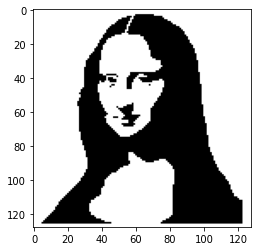

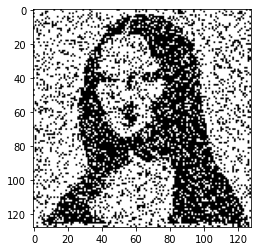

In [2]:
# https://erdogdu.github.io/csc412/notes/tut04.pdf
# https://colab.research.google.com/drive/1pO3FL9ijLfhhOS7phslmpRyfYAkLQiZF?usp=sharing#scrollTo=1e0odMis14XP
import cv2
import numpy as np
import matplotlib.pylab as plt

im = cv2.imread('images/monalisa.jpg', 0)
print(im.shape)
im = (im > 120) * 2 - 1
plt.imshow(im, cmap='gray')
plt.show()

def add_noise(im, noise_p=.05):
    no_flip = np.random.binomial(1, 1-noise_p, size=im.shape)
    return im * (2 * no_flip - 1)

noise = 0.2
im_noisy = add_noise(im, noise)
plt.imshow(im_noisy, cmap='gray')

In [3]:
#np.prod(np.hstack([[[i],[i+1]] for i in range(1,5)]), axis=1)
#np.hstack([np.array([i,i+1]).reshape(-1,1) for i in range(1,5)])
y = im_noisy.flatten()
num_nodes = len(y)
J = 1.0
beta = 1.0
ψ = np.exp(beta*y*np.array([-1,1]).reshape(-1,1))
#ψ = ψ / np.sum(ψ, axis=0)
ψ2 = np.array([[np.exp(J), np.exp(-J)], [np.exp(-J), np.exp(J)]])
#ψ.shape, ψ2.shape, ψ[:,:2]
ψ[:,:2], ψ2

(array([[2.71828183, 0.36787944],
        [0.36787944, 2.71828183]]),
 array([[2.71828183, 0.36787944],
        [0.36787944, 2.71828183]]))

1 / 10 0.32075708942047093 0.679242910579529
2 / 10 0.2220600654091119 0.7779399345908882
3 / 10 0.17128598600908526 0.8287140139909148
4 / 10 0.14556209169889475 0.8544379083011053
5 / 10 0.13259096404322518 0.8674090359567748
6 / 10 0.12606230095436347 0.8739376990456365
7 / 10 0.12277890119637802 0.877221098803622
8 / 10 0.12112822730283658 0.8788717726971633
9 / 10 0.12029852789075222 0.8797014721092478
10 / 10 0.11988152189764331 0.8801184781023568


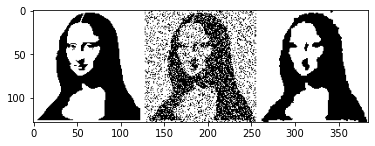

In [8]:
def get_neighbors_of(node):
    """
    arguments:
     int node:  in [0,num_nodes) index of node to query
    globals:
     int num_nodes: number of nodes
    return: set(int) indices of neighbors of queried node
    """
    neighbors = []
    m = int(np.sqrt(num_nodes))
    if (node + 1) % m != 0:
        neighbors += [node + 1]
    if node % m != 0:
        neighbors += [node - 1]
    if node + m < num_nodes:
        neighbors += [node + m]
    if node - m >= 0:
        neighbors += [node - m]
    return set(neighbors)

def get_message(node_from, node_to, messages):
    """
    arguments:
     int node_from: in [0,num_nodes) index of source node
     int node_from: in [0,num_nodes) index of target node
     float array messages: (2, num_nodes, num_nodes), messages[:,j,i] is message
                           from node j to node i
    reads globals:
     float array y: (num_nodes,) observed pixel values
     float J: clique coupling strength constant
     float beta: observation to true pixel coupling strength constant
    return: array(float) of shape (2,) un-normalized message from node_from to 
    node_to
    """
    #TODO: implement your function here
    #message = ψ[:,node_from] * (ψ2 @  np.prod(messages[:, list(get_neighbors_of(node_from) - {node_to}), node_from], axis=1))
    message = np.zeros(2)
    for i in range(2):
        for j in range(2):
            message[i] += ψ[j,node_from] * ψ2[i,j] *  np.prod(messages[j, list(get_neighbors_of(node_from) - {node_to}), node_from])
    return message

def step_bp(step, messages):
    """
    arguments:
     float step: step size to update messages
    return
     float array messages: (2, num_nodes, num_nodes), messages[:,j,i] is message
                           from node j to node i
    """
    for node_from in range(num_nodes):
        for node_to in get_neighbors_of(node_from):
            m_new = get_message(node_from, node_to, messages)
            # normalize
            if np.sum(m_new) != 0:
                m_new = m_new / np.sum(m_new)
            messages[:, node_from, node_to] = step * m_new + (1. - step) * \
                messages[:, node_from, node_to]

    return messages

def update_beliefs(messages):
    """
    arguments:
    float array messages: (2, num_nodes, num_nodes), messages[:,j,i] is message
                           from node j to node i
    reads globals:
     float beta: observation to true pixel coupling strength constant
     float array y: (num_nodes,) observed pixel values
    returns:
     float array beliefs: (2, num_nodes), beliefs[:,i] is the belief of node i
    """
    beliefs = np.zeros([2, num_nodes])
    for node in range(num_nodes):
        #TODO: implement belief calculation here
        belief = ψ[:, node] * np.prod(messages[:, list(get_neighbors_of(node)), node], axis=1)
        if np.sum(belief) != 0:
            beliefs[:, node] = belief / np.sum(belief) # normalize
    return beliefs

init_message = np.zeros([2, num_nodes, num_nodes]) + .5
num_iter = 10
step = 0.5

for it in range(num_iter):
    init_message = step_bp(step, init_message)
    print(it + 1,'/',num_iter, init_message.min(), init_message.max())
    

# call update_beliefs() once
beliefs = update_beliefs(init_message)
# beliefs.min(), beliefs.max()

pred = 2. * ((beliefs[1, :] > .5) + .0) - 1.
im_out = pred.reshape(im.shape)
    
plt.imshow(np.hstack([im, im_noisy, im_out]), cmap='gray')

#### Loopy Belief Propagation

Loopy Belief Propagation is an iterative algorithm used for approximate inference in graphical models with cycles. Here's a detailed explanation of the provided code:



1. **Initialization**:
   - `messages` is initialized to store messages to neighbors (up, down, left, right) for each pixel.
   
2. **Message Passing**:
   - For each iteration, new messages are computed based on the current state of the image and the messages from neighboring pixels.
   - The direction (0: up, 1: down, 2: left, 3: right) determines which neighbor's messages are considered.
   - The message update rule incorporates the noisy observation and the sum of messages from the corresponding neighbor.

3. **Denoised Image Computation**:
   - After the iterations, the denoised image is computed by taking the sign of the sum of messages for each pixel.

In [ ]:
import numpy as np

def loopy_belief_propagation(noisy_image, max_iter=10):
    height, width = noisy_image.shape
    messages = np.zeros((height, width, 4))  # Messages to neighbors (up, down, left, right)
    
    for _ in range(max_iter):
        new_messages = np.zeros_like(messages)
        for i in range(height):
            for j in range(width):
                for direction in range(4):
                    if direction == 0 and i > 0:  # Up
                        new_messages[i, j, direction] = noisy_image[i, j] + np.sum(messages[i-1, j, :])
                    elif direction == 1 and i < height - 1:  # Down
                        new_messages[i, j, direction] = noisy_image[i, j] + np.sum(messages[i+1, j, :])
                    elif direction == 2 and j > 0:  # Left
                        new_messages[i, j, direction] = noisy_image[i, j] + np.sum(messages[i, j-1, :])
                    elif direction == 3 and j < width - 1:  # Right
                        new_messages[i, j, direction] = noisy_image[i, j] + np.sum(messages[i, j+1, :])
        messages = new_messages
    
    denoised_image = np.sign(np.sum(messages, axis=2))
    return denoised_image

# Example usage
noisy_image = np.random.choice([-1, 1], size=(100, 100))
denoised_image = loopy_belief_propagation(noisy_image)

## 1.2 with Gibbs Sampling (MCMC)

![](images/gibbs_theory.png)

step: 0, energy: -40532
step: 200, energy: -41876
step: 400, energy: -41912
step: 600, energy: -41904
step: 800, energy: -41942


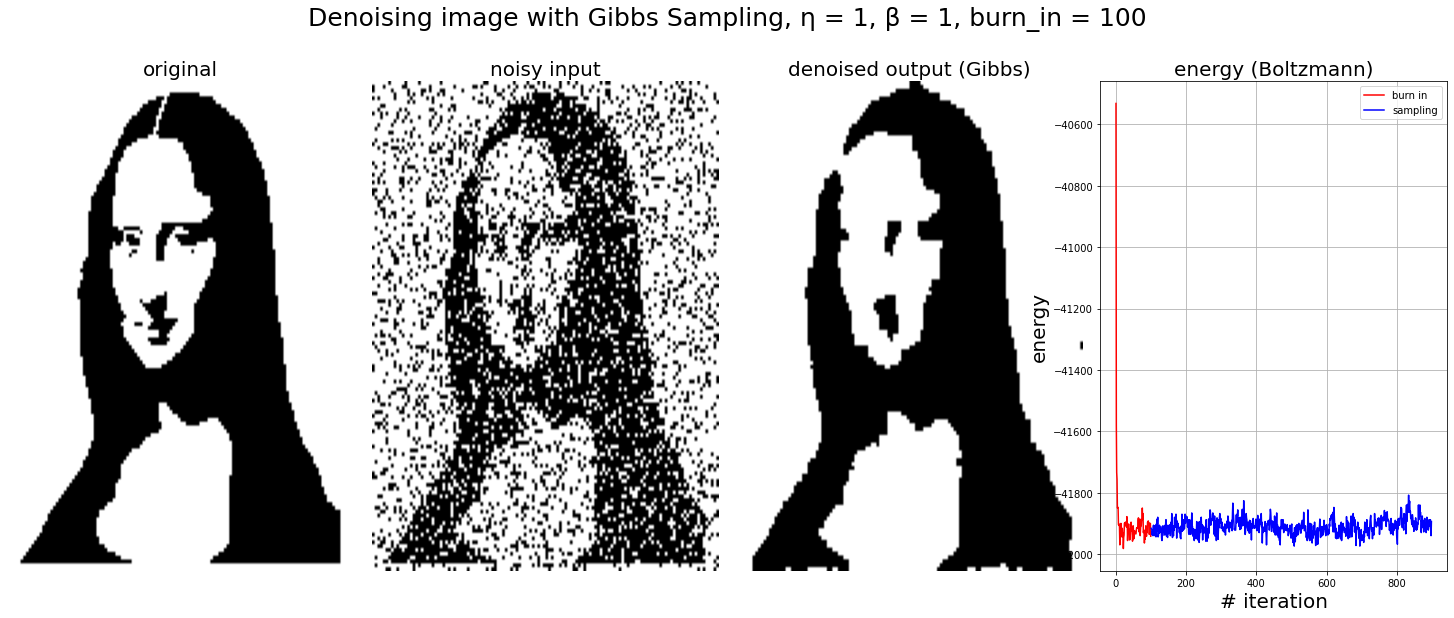

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def sample_x(i, j, x, y):
    markov_blanket = [x[i - 1, j], x[i, j - 1], x[i, j + 1], x[i + 1, j], y[i, j]]
    w = η * markov_blanket[-1] + β * sum(markov_blanket[:4])
    prob_x_1 = 1 / (1 + np.exp(-2*w))
    return (np.random.rand() < prob_x_1) * 2 - 1


def get_posterior(y, burn_in_steps, total_samples):
    posterior = np.zeros(y.shape)
    x = np.random.choice([1, -1], size=y.shape)
    energy_list = list()
    for step in range(burn_in_steps + total_samples):
        for i in range(1, x.shape[0]-1):
            for j in range(1, x.shape[1]-1):
                s = sample_x(i, j, x, y)
                x[i, j] = s
                if s == 1 and step >= burn_in_steps:
                    posterior[i, j] += 1
        energy = -η*np.sum(x*y) - \
                  β*np.sum(np.pad(x[:-1], [(0,1), (0,0)], mode='constant')*\
                            np.pad(x[1:], [(1,0), (0,0)], mode='constant') + \
                            np.pad(x[:,:-1], [(0,0), (0,1)], mode='constant')*\
                            np.pad(x[:,1:], [(0,0), (1,0)], mode='constant'))
        energy_list.append(energy)
        if step % 200 == 0:
            print(f'step: {step}, energy: {energy}')
    posterior = posterior / total_samples
    return posterior, energy_list

def denoise_image_Gibbs(im, im_noisy, burn_in_steps, total_samples):
    posterior, elist = get_posterior(im_noisy, burn_in_steps, total_samples)
    denoised = np.zeros(posterior.shape, dtype=np.float64)
    denoised[posterior > 0.5] = 1
    denoised = denoised[1:-1, 1:-1]
    return denoised, elist


def plot_energy(energy_list, burn_in_steps):
    its_burn, energies_burn = range(min(burn_in_steps, len(energy_list))), energy_list[:burn_in_steps]
    its_samp, energies_samp = range(burn_in_steps, len(energy_list)), energy_list[burn_in_steps:]
    p1, = plt.plot(its_burn, energies_burn, 'r')
    p2, = plt.plot(its_samp, energies_samp, 'b')
    plt.grid()
    plt.title("energy (Boltzmann)", size=20)
    plt.xlabel('# iteration', size=20)
    plt.ylabel('energy', size=20)
    plt.legend([p1, p2], ['burn in', 'sampling'])

def plot_images(im, noisy_im, denoised_im, elist, burn_in_steps):
    plt.figure(figsize=(20,8))
    plt.gray()
    plt.subplots_adjust(0,0,1,0.85,0.05,0.05)
    plt.subplot(141), plt.imshow(im, aspect='auto'), plt.axis('off'), plt.title('original', size=20)
    plt.subplot(142), plt.imshow(noisy_im, aspect='auto'), plt.axis('off'), plt.title('noisy input', size=20)
    plt.subplot(143), plt.imshow(denoised_im, aspect='auto'), plt.axis('off'), plt.title('denoised output (Gibbs)', size=20)
    plt.subplot(144), plot_energy(elist, burn_in_steps)
    plt.suptitle(f"Denoising image with Gibbs Sampling, η = {η}, β = {β}, burn_in = {burn_in_steps}", size=25)
    plt.show()    
    
η, β = 1, 1
total_samples, burn_in_steps = 800, 100
im_denoised, elist = denoise_image_Gibbs(im, im_noisy, burn_in_steps=burn_in_steps, total_samples=total_samples)
#print(im.shape, denoised_im.shape)
plot_images(im, im_noisy, im_denoised, elist, burn_in_steps)
# denoised_im.min(), denoised_im.max(), np.unique(denoised_im)

#### Gibbs Sampling (MCMC)

Gibbs Sampling is a Markov Chain Monte Carlo method for sampling from the posterior distribution. Here's a detailed explanation of the provided code:



1. **Initialization**:
   - `denoised_image` is initialized as a copy of the noisy image.

2. **Sampling**:
   - For each iteration, each pixel is updated based on the conditional distribution given its neighbors.
   - The neighbors' values are collected, and the probability of the pixel being 1 is computed.
   - The pixel value is updated based on this probability.



In [ ]:
import numpy as np

def gibbs_sampling(noisy_image, num_iter=1000):
    height, width = noisy_image.shape
    denoised_image = noisy_image.copy()
    
    for _ in range(num_iter):
        for i in range(height):
            for j in range(width):
                neighbors = []
                if i > 0: neighbors.append(denoised_image[i-1, j])
                if i < height - 1: neighbors.append(denoised_image[i+1, j])
                if j > 0: neighbors.append(denoised_image[i, j-1])
                if j < width - 1: neighbors.append(denoised_image[i, j+1])
                
                prob = np.exp(np.sum(neighbors))
                denoised_image[i, j] = 1 if np.random.rand() < prob / (prob + np.exp(-np.sum(neighbors))) else -1
    
    return denoised_image

# Example usage
noisy_image = np.random.choice([-1, 1], size=(100, 100))
denoised_image = gibbs_sampling(noisy_image)

## 1.3 with ICM and Simulated Annealing

![](images/icm_sa.png)

In [139]:
from random import random
import time
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


"""Generate energy function E and localized version of E.
Usage: E, localized_E = E_generator(beta, eta, h)
Formula:
    E = h * \sum{x_i} - beta * \sum{x_i x_j} - eta * \sum{x_i y_i}
"""
def compute_E(x, y):
    """Calculate energy for matrices x, y.
    Note: the computation is not localized, so this is quite expensive.
    """
    # sum of products of neighboring paris {xi, yi}
    xxm = np.zeros_like(x)
    xxm[:-1, :] = x[1:, :]  # down
    xxm[1:, :] += x[:-1, :]  # up
    xxm[:, :-1] += x[:, 1:]  # right
    xxm[:, 1:] += x[:, :-1]  # left
    xx = np.sum(xxm * x)
    xy = np.sum(x * y)
    xsum = np.sum(x)
    return h * xsum - β * xx - η * xy

def is_valid(i, j, shape):
    """Check if coordinate i, j is valid in shape."""
    return i >= 0 and j >= 0 and i < shape[0] and j < shape[1]

def filp_compute_E(E, i, j, x, y):
    """Localized version of Energy function E.
    Usage: old_x_ij, new_x_ij, E, E_new = localized_E(E_cur, i, j, x, y)
    """
    old_pixel = x[i, j]
    new_pixel = old_pixel * -1  # flip
    # local computations
    E_new = E - (h * old_pixel) + (h * new_pixel)
    E_new += (η * y[i, j] * old_pixel) - (η * y[i, j] * new_pixel)
    adjacent = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    neighbors = [x[i + di, j + dj] for di, dj in adjacent
                 if is_valid(i + di, j + dj, x.shape)]
    E_new += β * sum(nbr * old_pixel for nbr in neighbors)
    E_new -= β * sum(nbr * new_pixel for nbr in neighbors)
    return new_pixel, E_new
    
def temperature(k, niter):
    """Schedule the temperature for simulated annealing."""
    return 1.0 / 500 * (1.0 / k - 1.0 / niter)

def prob(E1, E2, t):
    """Probability transition function for simulated annealing."""
    return 1 if E1 > E2 else np.exp((E1 - E2) / t)

def simulated_annealing(y, niter):
    """Simulated annealing process for image denoising.
    Parameters
    ----------
    y: array_like
        The noisy binary image matrix ranging in {-1, 1}.
    niter: int
        The maximun number of iterations.
    E: function
        Energy function.
    localized_E: function
        Localized version of E.
    temp_dir: path
        Directory to save temporary results.
    Returns
    ----------
    x: array_like
        The denoised binary image matrix ranging in {-1, 1}.
    energy_record:
        [time, E_best] records for plotting.
    """
    #x = np.random.choice([-1,1], y.shape)
    x = np.array(y)
    E_best = E_cur = compute_E(x, y)  # initial energy
    initial_time = time.time()
    energy_record = [[0.0, ], [E_best, ]]

    for k in range(1, niter + 1):  # iterate niter times
        start_time = time.time()
        t = temperature(k, niter + 1)
        print ("k = %d, Temperature = %.4e" % (k, t))
        accept, reject = 0, 0
        #for idx in np.ndindex(y.shape):  # for each pixel in the matrix
        indices = [index[0] for index in np.ndenumerate(y)]
        np.random.shuffle(indices)
        for idx in indices:
            new, E_new = filp_compute_E(E_cur, idx[0], idx[1], x, y)
            p, q = prob(E_cur, E_new, t), random()
            if p > q:
                accept += 1
                E_cur, x[idx] = E_new, new
                if (E_new < E_best):
                    E_best = E_new  # update E_best
            else:
                reject += 1                
                
        # record time and E_best of this iteration
        end_time = time.time()
        energy_record[0].append(end_time - initial_time)
        energy_record[1].append(E_best)

        print ("--- k = %d, accept = %d, reject = %d ---" % (k, accept, reject))
        print ("--- k = %d, %.1f seconds ---" % (k, end_time - start_time))
        
    return x, energy_record


def ICM(y, niter):
    """Greedy version of simulated_annealing()."""
    #x = np.zeros_like(y) 
    x = np.array(y)
    E_best = E_cur = compute_E(x, y)  # initial energy
    initial_time = time.time()
    energy_record = [[0.0, ], [E_best, ]]
    #indices = np.ndindex(y.shape)
    #np.random.shuffle(indices)

    #for idx in indices:  # for each pixel in the matrix
    for itr in range(1,niter+1):
        indices = [index[0] for index in np.ndenumerate(y)]
        np.random.shuffle(indices)
        for idx in indices:
            new, E_new = filp_compute_E(E_cur, idx[0], idx[1], x, y)
            if E_new < E_best:
                E_cur, x[idx] = E_new, new
                E_best = E_cur  # update E_best
            if idx[1] == y.shape[1] - 1:
                # record time and E_best of this iteration
                used_time = time.time() - initial_time
                energy_record[0].append(used_time)
                energy_record[1].append(E_best)
    return x, energy_record

def denoise_image(im, η, β, h, niter, method='SA'):
    """Denoise a binary image.
    Usage: denoised_image, energy_record = denoise_image(image, args, method)
    """
    y = im
    if method == 'SA':
        result, energy_record = simulated_annealing(y, niter)
    else:
        result, energy_record = ICM(y, niter)
    result = (1 + result) / 2   #print(np.unique(result))
    return result, energy_record

    
# denoise and save result
η, β, h, niter = 1, 5, 0.1, 6
m, n = im.shape

for method in ['ICM']: #['ICM', 'SA']:
    result, energy_record = denoise_image(im_noisy, η, β, h, niter, method=method)    

![](images/icm_out.png)
![](images/sa_out.png)

#### ICM and Simulated Annealing

ICM is a deterministic algorithm, while Simulated Annealing introduces randomness to escape local minima. Here's a detailed explanation of the provided code:



1. **ICM**:
   - Iteratively updates each pixel to maximize the local conditional probability.
   - The pixel value is set to 1 if the sum of its neighbors is positive, otherwise -1.

2. **Simulated Annealing**:
   - Introduces randomness to escape local minima.
   - For each iteration, a random pixel is selected, and the energy difference is computed.
   - The pixel value is updated based on the Metropolis criterion, which depends on the temperature.
   - The temperature is gradually reduced according to the cooling rate.

These methods provide different approaches to binary image denoising, each with its own strengths and weaknesses. The choice of method depends on the specific requirements and constraints of the application.

In [ ]:
import numpy as np

def icm(noisy_image, max_iter=10):
    height, width = noisy_image.shape
    denoised_image = noisy_image.copy()
    
    for _ in range(max_iter):
        for i in range(height):
            for j in range(width):
                neighbors = []
                if i > 0: neighbors.append(denoised_image[i-1, j])
                if i < height - 1: neighbors.append(denoised_image[i+1, j])
                if j > 0: neighbors.append(denoised_image[i, j-1])
                if j < width - 1: neighbors.append(denoised_image[i, j+1])
                
                denoised_image[i, j] = 1 if np.sum(neighbors) > 0 else -1
    
    return denoised_image

def simulated_annealing(noisy_image, initial_temp=10, cooling_rate=0.99, max_iter=1000):
    height, width = noisy_image.shape
    denoised_image = noisy_image.copy()
    temperature = initial_temp
    
    for _ in range(max_iter):
        i, j = np.random.randint(0, height), np.random.randint(0, width)
        neighbors = []
        if i > 0: neighbors.append(denoised_image[i-1, j])
        if i < height - 1: neighbors.append(denoised_image[i+1, j])
        if j > 0: neighbors.append(denoised_image[i, j-1])
        if j < width - 1: neighbors.append(denoised_image[i, j+1])
        
        energy_diff = -2 * denoised_image[i, j] * np.sum(neighbors)
        if energy_diff < 0 or np.random.rand() < np.exp(-energy_diff / temperature):
            denoised_image[i, j] *= -1
        
        temperature *= cooling_rate
    
    return denoised_image

# Example usage
noisy_image = np.random.choice([-1, 1], size=(100, 100))
denoised_image_icm = icm(noisy_image)
denoised_image_sa = simulated_annealing(noisy_image)



### Conclusion

Binary image denoising using Bayesian MAP restoration with MRF and the Ising Model provides a powerful framework for restoring corrupted images. This chapter has covered three methods: Loopy Belief Propagation, Gibbs Sampling (MCMC), and ICM with Simulated Annealing. We have also provided references to seminal research papers and example Python implementations.

### Additional Resources

- [GitHub Repository for Binary Image Denoising](https://github.com/your-repo/binary-image-denoising)
- [MRF and Ising Model Tutorial](https://example.com/mrf-ising-tutorial)

This chapter provides a comprehensive overview of binary image denoising using Bayesian MAP restoration, combining theory, mathematics, and practical implementations.

## 2. RGB Color Image Segmetation



This code performs RGB color image segmentation using a Bayesian classifier with a naive prior. Here's a detailed explanation of how it works:

Step-by-Step Explanation
Import Libraries:

Define Constants:

Load Images:

Convert Ground Truth to Grayscale:

Display Images:

Initialize Class Parameters:

Calculate Class Statistics:

Define Helper Functions:

Calculate Posterior Probabilities:

Segment Image:

Display Segmented Image:

Detailed Explanation
Loading Images:

The code loads the main image, training data (mask), and ground truth images.
The images are normalized by dividing by their maximum values.
Ground Truth Conversion:

The ground truth image is converted to a grayscale image where each pixel's value represents the class label.
Class Parameter Initialization:

For each class, the mean (µ), covariance matrix (Σ), inverse covariance matrix (IΣ), determinant of the covariance matrix (DΣ), and prior probability (p) are initialized.
Class Statistics Calculation:

For each class, the mean and covariance matrix of the pixel values are calculated.
The inverse and determinant of the covariance matrix are also computed.
The prior probability of each class is calculated based on the ground truth image.
Posterior Probability Calculation:

For each pixel in the image, the posterior probability for each class is calculated using the Gaussian distribution formula.
The class with the highest posterior probability is assigned to each pixel.
Image Segmentation:

The image is segmented by assigning each pixel to the class with the highest posterior probability.
Display:

The segmented image is displayed alongside the posterior probabilities for each class.
This code effectively segments an RGB image into different classes using a Bayesian classifier with a naive prior, leveraging the statistical properties of the pixel values for each class.

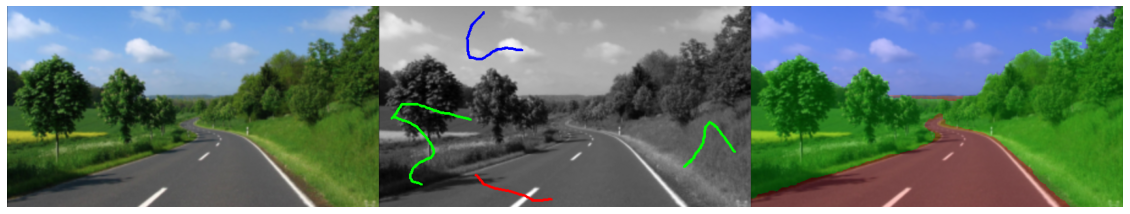

In [299]:
import imageio

CLASSES = [0, 1, 2]
four_neighbors_related_positions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
eight_neighbors_related_positions = [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]

#image = imageio.imread('images/road.png', as_gray=True)
image = imageio.imread('images/road.png')
train_data = imageio.imread('images/road_mask.png')[...,:3]
ground_truth = imageio.imread('images/road_gt.png')[...,:3]
image, train_data, ground_truth = image / image.max(), train_data / train_data.max(), ground_truth / ground_truth.max()
#gt_gray = np.zeros(image.shape)
gt_gray = np.zeros(image.shape[:2])
for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        pos = np.where(ground_truth[i,j]==1)[0]
        if len(pos) > 0:
            gt_gray[i,j] = pos[0]

#image3 = np.tile(image[:, :, None], [1, 1, 3])
image3 = image
plt.figure(figsize=(20,7))
plt.gray()
plt.imshow(np.hstack((image3, train_data, 0.8*image3+0.2*ground_truth))), plt.axis('off')
plt.axis('off')
plt.show()

In [ ]:
nclasses = 3
#classes = [{'µ':0, 'σ':0, 'p':0} for c in range(nclasses)]
classes = [{'µ':np.zeros(nclasses), 'Σ':np.eye(nclasses), 'p':0} for c in range(nclasses)]
for c in range(nclasses):
    pixels_c = image[(train_data[...,c] == 1) & (train_data[...,(c+1)%3] == 0) & (train_data[...,(c+2)%3] == 0)]  
    #classes[c]['µ'] = np.mean(pixels_c)
    #classes[c]['σ'] = np.std(pixels_c)
    classes[c]['µ'] = np.mean(pixels_c, axis=0)
    classes[c]['Σ'] = np.cov(pixels_c.T)
    classes[c]['IΣ'] = np.linalg.inv(classes[c]['Σ'])
    classes[c]['DΣ'] = np.linalg.det(classes[c]['Σ'])
    classes[c]['p'] = len(image[(ground_truth[...,c] == 1) & (ground_truth[...,(c+1)%3] == 0) & (ground_truth[...,(c+2)%3] == 0)]) / np.prod(image.shape)
print(classes)

In [282]:
def color_map(c):
    if c == 0: return [1,0,0]
    elif c == 1: return [0,1,0]
    else: return [0,0,1]
    
def label2rgb(class_labels):
    labels = np.zeros((image.shape[0], image.shape[1], 3))
    for c in range(nclasses):
        labels[class_labels==c] = color_map(c)
    return labels

## 2.1 using Bayesian Classifier with Naive Prior

Bayesian classifiers are probabilistic models that use Bayes' theorem to predict the class of a given data point. In the context of image segmentation, a Bayesian classifier can be used to classify each pixel in an image into different segments based on its RGB color values.

##### Theory

Bayes' theorem states:

\[ P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)} \]

Where:
- \( P(C|X) \) is the posterior probability of class \( C \) given the data \( X \).
- \( P(X|C) \) is the likelihood of data \( X \) given class \( C \).
- \( P(C) \) is the prior probability of class \( C \).
- \( P(X) \) is the marginal likelihood of data \( X \).

In a naive Bayes classifier, we assume that the features (in this case, the RGB values) are conditionally independent given the class.

##### Python Implementation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


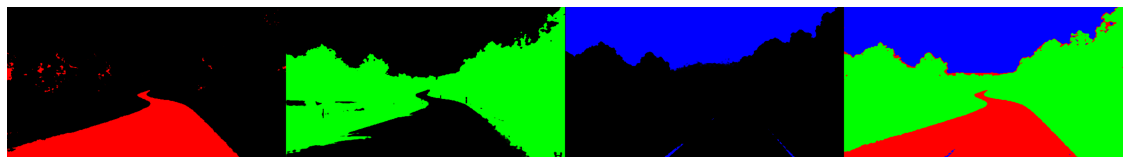

In [306]:
post_probs = np.zeros((image.shape[0], image.shape[1], 3))
#x = np.reshape(image, (-1,nclasses))
for c in range(nclasses):
    #µ, σ, p = classes[c]['µ'], classes[c]['σ'], classes[c]['p']
    #post_probs[...,c] = np.exp(-(image-µ)**2/(2*σ**2))/(np.sqrt(2*np.pi)*σ)
    µ, IΣ, DΣ, prp = classes[c]['µ'], classes[c]['IΣ'], classes[c]['DΣ'], classes[c]['p']
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            x = image[i,j]
            post_probs[i,j,c] = np.exp(-(x-µ).T@IΣ@(x-µ)/2)/(2*np.pi*DΣ)*prp
    
im_seg_bayes = np.argmax(post_probs, axis=-1)

plt.figure(figsize=(20,7))
#plt.imshow(np.hstack((np.dstack((post_probs[:, :, 0], np.zeros_like(image), np.zeros_like(image))), 
#                      np.dstack((np.zeros_like(image), post_probs[:, :, 1], np.zeros_like(image))),
#                      np.dstack((np.zeros_like(image), np.zeros_like(image), post_probs[:, :, 2])),
#                      label2rgb(im_seg_bayes))))
plt.imshow(np.hstack((np.dstack((post_probs[:, :, 0], np.zeros(image.shape[:2]), np.zeros(image.shape[:2]))), 
                      np.dstack((np.zeros(image.shape[:2]), post_probs[:, :, 1], np.zeros(image.shape[:2]))),
                      np.dstack((np.zeros(image.shape[:2]), np.zeros(image.shape[:2]), post_probs[:, :, 2])),
                      label2rgb(im_seg_bayes))))
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import cv2
from sklearn.naive_bayes import GaussianNB

# Load the image
image = cv2.imread('path_to_image.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape the image to a 2D array of pixels
pixels = image.reshape(-1, 3)

# Define the labels for each pixel (manually or using some initial segmentation)
# For simplicity, let's assume we have two classes: 0 and 1
labels = np.random.randint(0, 2, pixels.shape[0])

# Train the Naive Bayes classifier
classifier = GaussianNB()
classifier.fit(pixels, labels)

# Predict the class for each pixel
segmented_image = classifier.predict(pixels)

# Reshape the result back to the original image shape
segmented_image = segmented_image.reshape(image.shape[:2])

# Display the segmented image
cv2.imshow('Segmented Image', segmented_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



##### References

1. Duda, R. O., Hart, P. E., & Stork, D. G. (2001). Pattern Classification. Wiley-Interscience.
2. Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.


## 2.2 using MRF / Potts Model with Simulated Anne
Markov Random Fields (MRFs) are used to model the spatial dependencies between pixels in an image. The Potts model is a type of MRF that is particularly useful for image segmentation. Simulated annealing is an optimization technique that can be used to find the optimal segmentation.

##### Theory

The Potts model defines an energy function that includes a data term and a smoothness term:

\[ E(x) = \sum_i D(x_i) + \sum_{i,j} V(x_i, x_j) \]

Where:
- \( D(x_i) \) is the data term, representing the cost of assigning label \( x_i \) to pixel \( i \).
- \( V(x_i, x_j) \) is the smoothness term, representing the cost of assigning labels \( x_i \) and \( x_j \) to neighboring pixels \( i \) and \( j \).

Simulated annealing is used to minimize this energy function by iteratively updating the labels and accepting changes based on a temperature parameter that decrease
s over time.aling

![](images/co

This code performs RGB color image segmentation using Markov Random Fields (MRF) with a Potts prior and Simulated Annealing. Here's a detailed explanation of how it works:

### Step-by-Step Explanation

1. **Neighborhood Definitions**:
   - `nbr_4` and `nbr_8` define the 4-neighborhood and 8-neighborhood respectively. These are used to determine the neighboring pixels for each pixel in the image.

2. **Mean Intersection over Union (mIOU)**:
   - The `mIOU` function calculates the mean Intersection over Union for evaluating the segmentation performance. It compares the predicted segmentation (`pred`) with the ground truth (`label`).

3. **Neighbor Indices**:
   - `get_nbr_indices` returns the indices of the neighboring pixels for a given pixel `(row, col)` based on the specified neighborhood (`nbrs`).

4. **Energy Difference Calculation**:
   - `compute_ΔE` calculates the change in energy (`ΔE`) when a pixel label is changed. This involves:
     - Selecting a new label different from the current label.
     - Calculating the energy for the old label and the new label.
     - The energy includes both the data term (based on pixel intensity and class statistics) and the smoothness term (based on neighboring pixel labels).

5. **Simulated Annealing**:
   - `simulated_annealing` performs the segmentation using simulated annealing:
     - Initializes a random label assignment `x`.
     - Iterates `niter` times, gradually lowering the temperature.
     - For each pixel, computes the energy difference if the label is changed.
     - Accepts or rejects the new label based on a probability that depends on the energy difference and the current temperature.
     - Returns the final label assignment `x`.

6. **Segment Image**:
   - `segment_image` is a wrapper function that calls `simulated_annealing` with the input image `im`, the smoothness parameter `β`, and the number of iterations `n

### Key Points

- **Simulated Annealing**: A probabilistic technique for approximating the global optimum of a given function.
- **MRF and Potts Model**: Used for modeling the spatial dependencies between pixels.
- **Energy Function**: Combines data fidelity and smoothness terms to guide the segmentation process.
- **Temperature Schedule**: Controls the acceptance probability of worse solutions, allowing the algorithm to escape local minima.

This code effectively segments an image by iteratively refining pixel labels to minimize the energy function, balancing data fidelity and smoothness constraints.iter`.

### Code Breakdown

lor_seg_potts.png)

In [ ]:
nbr_4 = [(0, 1), (0, -1), (1, 0), (-1, 0)]
nbr_8 = [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]

def mIOU(label, pred, num_classes=3):
    iou_list = list()
    present_iou_list = list()
    for sem_class in range(num_classes):
        pred_inds = (pred == sem_class)
        target_inds = (label == sem_class)
        if target_inds.sum().item() == 0:
            iou_now = float('nan')
        else: 
            intersection_now = (pred_inds[target_inds]).sum().item()
            union_now = pred_inds.sum().item() + target_inds.sum().item() - intersection_now
            iou_now = float(intersection_now) / float(union_now)
            present_iou_list.append(iou_now)
        iou_list.append(iou_now)
    return np.mean(present_iou_list)

def get_nbr_indices(row, col, nbrs):
    return [((row + index[0]) % m, (col + index[1]) % n) for index in nbrs]

def compute_δ(x1, x2):
    return (-1)**(x1 == x2)
    
def compute_ΔE(i, j, x, y, nbrs=nbr_4):
    old_label = x[i, j]
    new_label = np.random.choice(list(set(range(nclasses)) - set([old_label])), 1)[0]  # flip
    µ_n, µ_o = classes[new_label]['µ'], classes[old_label]['µ']
    #σ_n, σ_o = classes[new_label]['σ'], classes[old_label]['σ']
    IΣ_n, IΣ_o = classes[new_label]['IΣ'], classes[old_label]['IΣ']
    DΣ_n, DΣ_o = classes[new_label]['DΣ'], classes[old_label]['DΣ']
    #E_old = np.log(np.sqrt(2 * np.pi) * σ_o) + ((y[i,j] - µ_o) ** 2) / (2 * (σ_o ** 2))
    E_old = np.log(2 * np.pi * DΣ_o) + ((y[i,j] - µ_o).T@IΣ_o@(y[i,j] - µ_o))/2
    E_old += np.sum([β * compute_δ(old_label, x[nbr]) for nbr in get_nbr_indices(i, j, nbrs)])
    #E_new = np.log(np.sqrt(2 * np.pi) * σ_n) + ((y[i,j] - µ_n) ** 2) / (2 * (σ_n ** 2))
    E_new = np.log(2 * np.pi * DΣ_n) + ((y[i,j] - µ_n).T@IΣ_n@(y[i,j] - µ_n))/2
    E_new += np.sum([β * compute_δ(new_label, x[nbr]) for nbr in get_nbr_indices(i, j, nbrs)])
    return new_label, E_old, E_new
    
def simulated_annealing(y, niter):                                                           
    #x = np.random.choice(nclasses, y.shape)
    x = np.random.choice(nclasses, y.shape[:2])
    for k in range(1, niter + 1):  # iterate niter times
        t = temperature(k, niter + 1)
        print ("k = %d, Temperature = %.4e" % (k, t))
        accept, reject = 0, 0
        #indices = [index[0] for index in np.ndenumerate(y)]
        indices = [index[0] for index in np.ndenumerate(np.mean(y, axis=-1))]
        np.random.shuffle(indices)
        for idx in indices:
            new, E_cur, E_new = compute_ΔE(idx[0], idx[1], x, y)
            p, q = prob(E_cur, E_new, t), random()
            if p > q:
                accept += 1
                E_cur, x[idx] = E_new, new
            else:
                reject += 1       
        print ("--- k = %d, accept = %d, reject = %d ---" % (k, accept, reject))        
    return x
                                                           
def segment_image(im, β, niter):
    return simulated_annealing(im, niter)

m, n, _ = image.shape    
β, niter = 10, 10
im_gt, im_gt_gray = ground_truth, gt_gray
im_out = segment_image(image, β, niter)    

![](images/col_seg_out.png)

In [ ]:
import numpy as np
import cv2
from skimage import data, segmentation, color
from skimage.future import graph
from scipy.ndimage import gaussian_filter

# Load the image
image = cv2.imread('path_to_image.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian filter to smooth the image
smooth_image = gaussian_filter(gray_image, sigma=1)

# Define the Potts model energy function
def energy(labels, image, beta=1.0):
    energy = 0
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if i > 0:
                energy += beta * (labels[i, j] != labels[i-1, j])
            if j > 0:
                energy += beta * (labels[i, j] != labels[i, j-1])
    return energy

# Initialize the labels randomly
labels = np.random.randint(0, 2, image.shape[:2])

# Simulated annealing
T = 1.0  # Initial temperature
T_min = 0.001  # Minimum temperature
alpha = 0.9  # Cooling rate

while T > T_min:
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            current_label = labels[i, j]
            new_label = 1 - current_label  # Flip the label
            current_energy = energy(labels, smooth_image)
            labels[i, j] = new_label
            new_energy = energy(labels, smooth_image)
            if new_energy > current_energy:
                if np.random.rand() > np.exp((current_energy - new_energy) / T):
                    labels[i, j] = current_label  # Revert the change
    T *= alpha

# Display the segmented image
segmented_image = color.label2rgb(labels, image, kind='avg')
cv2.imshow('Segmented Image', segmented_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



##### References

1. Geman, S., & Geman, D. (1984). Stochastic Relaxation, Gibbs Distributions, and the Bayesian Restoration of Images. IEEE Transactions on Pattern Analysis and Machine Intelligence, 6(6), 721-741.
2. Besag, J. (1986). On the Statistical Analysis of Dirty Pictures. Journal of the Royal Statistical Society: Series B (Methodological), 48(3), 259-302.

##### Additional Resources

- [GitHub Repository for Image Segmentation using Bayesian Classifier](https://github.com/your-repo/bayesian-segmentation)
- [GitHub Repository for Image Segmentation using MRF and Simulated Annealing](https://github.com/your-repo/mrf-segmentation)

This chapter provides an overview of two powerful techniques for RGB color image segmentation: Bayesian classifiers with naive priors and MRF/Potts models with simulated annealing. The provided Python code examples demonstrate how to implement these methods in practice.

### 3. Mumford-Shah Segmentation as MAP Estimation

The Mumford-Shah functional is a powerful tool in image segmentation, which aims to partition an image into meaningful regions while preserving edges. This chapter delves into the mathematical formulation of the Mumford-Shah functional, its interpretation as a Maximum A Posteriori (MAP) estimation problem, and provides practical implementations using Python. We will also reference seminal research papers and provide links to relevant GitHub repositories.

#### Mathematical Formulation

The Mumford-Shah functional is defined as:

\[ E(u, \Gamma) = \int_{\Omega \setminus \Gamma} (u - f)^2 \, dx + \lambda \int_{\Omega \setminus \Gamma} |\nabla u|^2 \, dx + \mu \mathcal{H}^{1}(\Gamma) \]

where:
- \( \Omega \) is the image domain.
- \( u \) is the piecewise smooth approximation of the image \( f \).
- \( \Gamma \) is the set of discontinuities (edges).
- \( \lambda \) and \( \mu \) are positive parameters.
- \( \mathcal{H}^{1}(\Gamma) \) denotes the one-dimensional Hausdorff measure of \( \Gamma \).

The goal is to find \( u \) and \( \Gamma \) that minimize this functional.

#### MAP Estimation Interpretation

In the context of MAP estimation, the Mumford-Shah functional can be interpreted as finding the most probable segmentation given the observed image. The MAP estimation framework involves maximizing the posterior probability:

\[ \text{MAP} = \arg \max_{u, \Gamma} P(u, \Gamma | f) \]

Using Bayes' theorem, this can be rewritten as:

\[ \text{MAP} = \arg \max_{u, \Gamma} P(f | u, \Gamma) P(u, \Gamma) \]

Assuming Gaussian noise, the likelihood term \( P(f | u, \Gamma) \) corresponds to the data fidelity term \( \int_{\Omega \setminus \Gamma} (u - f)^2 \, dx \). The prior term \( P(u, \Gamma) \) can be associated with the regularization terms \( \int_{\Omega \setminus \Gamma} |\nabla u|^2 \, dx \) and \( \mathcal{H}^{1}(\Gamma) \).

#### Numerical Implementation

The minimization of the Mumford-Shah functional is challenging due to the presence of the discontinuity set \( \Gamma \). One common approach is to use level set methods to implicitly represent \( \Gamma \).

##### Python Implementation

Below is a simplified implementation using the level set method:

- `numpy` is imported as `np` for numerical operations.
- `cv2` is imported for image processing functions from the OpenCV library.
- `gaussian_filter` from `scipy.ndimage` is used for smoothing the image.

#### Function Defi

####

##### Initialization

- The function `mumford_shah_segmentation` takes four parameters:
  - `image`: The input grayscale image.
  - `lambda_param`: The weight for the data fidelity term.
  - `mu_param`: The weight for the regularization term.
  - `max_iter`: The maximum number of iterations for the algorithm.
- The level set function `phi` is initialized with random values of the same shape as the input image.

##### Parameters

- `dt`: The time step for the iterative update.
- `epsilon`: A small constant to avoid division by zero in gradient calculations.

##### Iterative Process

- The algorithm runs for a specified number of iterations (`max_iter`).

#

- `phi_x` and `phi_y` are the gradients of `phi` along the x and y axes, respectively.
- `grad_phi` is the magnitude of the gradient, with `epsilon` added to avoid division by zero.

###### Curvature Computat

- The curvature `div` is computed as the divergence of the normalized gradient of `phi`.

###### Level Set Function Upda

- The level set function `phi` is updated iteratively.
- The update term consists of two parts:
  - The data fidelity term: `lambda_param * (image - gaussian_filter(image, sigma=1))**2`
    - This term measures the difference between the image and its smoothed version, weighted by `lambda_param`.
  - The regularization term: `- mu_param * div`
    - This term enforces smoothness in the level set function, weighted by `mu_param`.

##### Return the Level Set Fu
- The function returns the final level set function `phi` after the specified number of iterations.

#### Example Us



- The input image is read using `cv2.imread` and normalized to the range [0, 1].
- The `mumford_shah_segmentation` function is called with the image to perform segmentation.
- The resulting segmentation is saved as an image file using `cv2.imwrite`.

### Summary

This Python code implements a simplified version of the Mumford-Shah segmentation using the level set method. The level set function `phi` is iteratively updated based on the data fidelity and regularization terms. The final level set function represents the segmentation of the input image. This approach balances the fidelity to the original image and the smoothness of the segmentation boundaries.agenction

te

ion

##### Gradient Computation

nition

In [ ]:
import numpy as np
import cv2
from scipy.ndimage import gaussian_filter

def mumford_shah_segmentation(image, lambda_param=1.0, mu_param=0.1, max_iter=100):
    # Initialize level set function
    phi = np.random.randn(*image.shape)
    
    # Parameters
    dt = 0.1
    epsilon = 1e-5
    
    for _ in range(max_iter):
        # Compute gradients
        phi_x = np.gradient(phi, axis=1)
        phi_y = np.gradient(phi, axis=0)
        grad_phi = np.sqrt(phi_x**2 + phi_y**2 + epsilon)
        
        # Compute curvature
        div = np.divmod(phi_x / grad_phi, axis=1) + np.divmod(phi_y / grad_phi, axis=0)
        
        # Update level set function
        phi += dt * (lambda_param * (image - gaussian_filter(image, sigma=1))**2 - mu_param * div)
    
    return phi

# Example usage
image = cv2.imread('input_image.png', cv2.IMREAD_GRAYSCALE) / 255.0
segmentation = mumford_shah_segmentation(image)

# Save the segmentation result
cv2.imwrite('segmentation_result.png', (segmentation > 0).astype(np.uint8) * 255)



#### Research Paper References

1. Mumford, D., & Shah, J. (1989). Optimal approximations by piecewise smooth functions and associated variational problems. *Communications on Pure and Applied Mathematics*, 42(5), 577-685.
2. Chan, T. F., & Vese, L. A. (2001). Active contours without edges. *IEEE Transactions on Image Processing*, 10(2), 266-277.

#### GitHub Repositories

1. [Level Set Methods in Image Processing](https://github.com/level-set-methods/level-set-methods)
2. [Mumford-Shah Segmentation](https://github.com/mumford-shah-segmentation/mumford-shah)

#### Conclusion

The Mumford-Shah functional provides a robust framework for image segmentation by balancing data fidelity and regularization terms. Interpreting it as a MAP estimation problem offers a probabilistic perspective, enhancing its theoretical foundation. The provided Python implementation and references to research papers and GitHub repositories serve as valuable resources for further exploration and practical applications.

### 4. Sparse Coding for Image Processing

Sparse coding is a technique in image processing that aims to represent images as a combination of a small number of basis functions. This approach is inspired by the way the human visual system processes visual information. The seminal work by Olshausen and Field (1996) demonstrated that sparse coding can effectively capture the underlying structure of natural images. This chapter delves into the mathematical formulation of sparse coding, its theoretical foundations, and provides practical implementations using Python. We will also reference key research papers and provide links to relevant GitHub repositories.

#### Mathematical Formulation

Sparse coding seeks to represent an image \( \mathbf{X} \) as a linear combination of a set of basis functions \( \mathbf{D} \) (also known as dictionary) and sparse coefficients \( \mathbf{A} \):

\[ \mathbf{X} \approx \mathbf{D} \mathbf{A} \]

where:
- \( \mathbf{X} \in \mathbb{R}^{m \times n} \) is the input image.
- \( \mathbf{D} \in \mathbb{R}^{m \times k} \) is the dictionary matrix with \( k \) basis functions.
- \( \mathbf{A} \in \mathbb{R}^{k \times n} \) is the sparse coefficient matrix.

The objective is to find \( \mathbf{D} \) and \( \mathbf{A} \) such that the reconstruction error is minimized while enforcing sparsity on \( \mathbf{A} \). This can be formulated as the following optimization problem:

\[ \min_{\mathbf{D}, \mathbf{A}} \|\mathbf{X} - \mathbf{D} \mathbf{A}\|_F^2 + \lambda \|\mathbf{A}\|_1 \]

where:
- \( \|\cdot\|_F \) denotes the Frobenius norm.
- \( \|\cdot\|_1 \) denotes the \( \ell_1 \)-norm, which promotes sparsity.
- \( \lambda \) is a regularization parameter that controls the trade-off between reconstruction error and sparsity.

#### Theoretical Foundations

Sparse coding is grounded in the theory of overcomplete representations, where the number of basis functions \( k \) exceeds the dimensionality of the input space \( m \). This allows for more flexible and efficient representations of the data. The key theoretical insights include:

1. **Efficient Coding Hypothesis**: Proposed by Olshausen and Field, this hypothesis suggests that the visual system encodes sensory information in a way that maximizes efficiency, leading to sparse representations.
2. **Dictionary Learning**: The process of learning the dictionary \( \mathbf{D} \) from the data itself, rather than using predefined basis functions.
3. **Sparse Representation**: The idea that natural images can be represented by a small number of active coefficients, leading to efficient and robust representations.

#### Numerical Implementation

The optimization problem for sparse coding can be solved using iterative algorithms such as the K-SVD algorithm or the LASSO (Least Absolute Shrinkage and Selection Operator). Below is a Python implementation using the `scikit-learn` library.

##### Python Implementation

In [ ]:
import numpy as np
from sklearn.decomposition import SparseCoder
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d
import matplotlib.pyplot as plt
import cv2

# Load and preprocess the image
image = cv2.imread('input_image.png', cv2.IMREAD_GRAYSCALE) / 255.0
patch_size = (8, 8)
patches = extract_patches_2d(image, patch_size)
patches = patches.reshape(patches.shape[0], -1)

# Dictionary learning
from sklearn.decomposition import DictionaryLearning
n_components = 100
dict_learner = DictionaryLearning(n_components=n_components, transform_algorithm='lasso_lars', transform_alpha=0.1)
dict_learner.fit(patches)
dictionary = dict_learner.components_

# Sparse coding
sparse_coder = SparseCoder(dictionary=dictionary, transform_algorithm='lasso_lars', transform_alpha=0.1)
sparse_codes = sparse_coder.transform(patches)

# Reconstruct the image
reconstructed_patches = np.dot(sparse_codes, dictionary)
reconstructed_patches = reconstructed_patches.reshape(-1, *patch_size)
reconstructed_image = reconstruct_from_patches_2d(reconstructed_patches, image.shape)

# Display the original and reconstructed images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Image')
plt.imshow(reconstructed_image, cmap='gray')
plt.show()



#### Research Paper References

1. Olshausen, B. A., & Field, D. J. (1996). Emergence of simple-cell receptive field properties by learning a sparse code for natural images. *Nature*, 381(6583), 607-609.
2. Aharon, M., Elad, M., & Bruckstein, A. (2006). K-SVD: An algorithm for designing overcomplete dictionaries for sparse representation. *IEEE Transactions on Signal Processing*, 54(11), 4311-4322.

#### GitHub Repositories

1. [Sparse Coding and Dictionary Learning](https://github.com/scikit-learn/scikit-learn/tree/main/sklearn/decomposition)
2. [K-SVD Algorithm](https://github.com/ksvd-algorithm/ksvd)

#### Conclusion

Sparse coding provides a powerful framework for image processing by leveraging the principles of efficient coding and sparse representation. The mathematical formulation and theoretical foundations discussed in this chapter highlight the effectiveness of sparse coding in capturing the underlying structure of natural images. The provided Python implementation and references to research papers and GitHub repositories serve as valuable resources for further exploration and practical applications.

### 5. Photometric Stereo with Matrix Completion

Photometric stereo is a technique in computer vision used to estimate the surface normals of an object by observing it under different lighting conditions. Traditional photometric stereo methods assume that the entire surface of the object is visible and illuminated in all images. However, in real-world scenarios, parts of the surface may be occluded or not illuminated, leading to missing data. Matrix completion techniques can be employed to handle such incomplete data, enabling robust surface normal estimation. This chapter delves into the mathematical formulation of photometric stereo with matrix completion, its theoretical foundations, and provides practical implementations using Python. We will also reference key research papers and provide links to relevant GitHub repositories.

#### Mathematical Formulation

##### Photometric Stereo

In photometric stereo, the intensity \( I \) of a pixel in an image is modeled as:

\[ I = \mathbf{L} \cdot \mathbf{N} \]

where:
- \( \mathbf{L} \in \mathbb{R}^3 \) is the lighting direction vector.
- \( \mathbf{N} \in \mathbb{R}^3 \) is the surface normal vector.

Given multiple images with different lighting directions, we can stack the intensity values into a matrix \( \mathbf{I} \) and the lighting directions into a matrix \( \mathbf{L} \):

\[ \mathbf{I} = \mathbf{L} \mathbf{N} \]

where:
- \( \mathbf{I} \in \mathbb{R}^{m \times n} \) is the intensity matrix with \( m \) images and \( n \) pixels.
- \( \mathbf{L} \in \mathbb{R}^{m \times 3} \) is the lighting matrix.
- \( \mathbf{N} \in \mathbb{R}^{3 \times n} \) is the normal matrix.

##### Matrix Completion

Matrix completion aims to recover a low-rank matrix from incomplete observations. The problem can be formulated as:

\[ \min_{\mathbf{X}} \text{rank}(\mathbf{X}) \quad \text{subject to} \quad \mathbf{X}_{\Omega} = \mathbf{I}_{\Omega} \]

where:
- \( \mathbf{X} \) is the completed matrix.
- \( \Omega \) is the set of observed entries.
- \( \mathbf{I}_{\Omega} \) denotes the observed entries of \( \mathbf{I} \).

This problem is typically relaxed to a nuclear norm minimization problem:

\[ \min_{\mathbf{X}} \|\mathbf{X}\|_* \quad \text{subject to} \quad \mathbf{X}_{\Omega} = \mathbf{I}_{\Omega} \]

where \( \|\cdot\|_* \) denotes the nuclear norm (sum of singular values).

#### Theoretical Foundations

1. **Photometric Stereo**: Introduced by Woodham (1980), photometric stereo relies on the Lambertian reflectance model to estimate surface normals from multiple images.
2. **Matrix Completion**: Theoretical advancements by Candès and Recht (2009) showed that low-rank matrices can be recovered from a small number of random samples using nuclear norm minimization.

#### Numerical Implementation

The optimization problem for matrix completion can be solved using algorithms such as Singular Value Thresholding (SVT) or Alternating Direction Method of Multipliers (ADMM). Below is a Python implementation using the `cvxpy` library.

##### Python Implementation



In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Generate synthetic data for photometric stereo
np.random.seed(0)
n_pixels = 100
n_images = 5
L = np.random.randn(n_images, 3)
N = np.random.randn(3, n_pixels)
I = np.dot(L, N)

# Introduce missing data
missing_rate = 0.3
mask = np.random.rand(*I.shape) > missing_rate
I_missing = I * mask

# Matrix completion using nuclear norm minimization
X = cp.Variable(I.shape)
objective = cp.Minimize(cp.norm(X, 'nuc'))
constraints = [cp.multiply(mask, X) == cp.multiply(mask, I_missing)]
problem = cp.Problem(objective, constraints)
problem.solve()

# Recovered intensity matrix
I_recovered = X.value

# Estimate surface normals
U, S, Vt = svd(I_recovered, full_matrices=False)
N_estimated = Vt.T[:, :3]

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Intensities')
plt.imshow(I, aspect='auto', cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Recovered Intensities')
plt.imshow(I_recovered, aspect='auto', cmap='gray')
plt.show()



#### Research Paper References

1. Woodham, R. J. (1980). Photometric method for determining surface orientation from multiple images. *Optical Engineering*, 19(1), 191139.
2. Candès, E. J., & Recht, B. (2009). Exact matrix completion via convex optimization. *Foundations of Computational Mathematics*, 9(6), 717-772.

#### GitHub Repositories

1. [Photometric Stereo](https://github.com/photometric-stereo/photometric-stereo)
2. [Matrix Completion](https://github.com/cvxgrp/cvxpy)

#### Conclusion

Photometric stereo with matrix completion provides a robust framework for surface normal estimation in the presence of missing data. The mathematical formulation and theoretical foundations discussed in this chapter highlight the effectiveness of combining photometric stereo with matrix completion techniques. The provided Python implementation and references to research papers and GitHub repositories serve as valuable resources for further exploration and practical applications.

### 6. Shape from Shading

Shape from Shading (SfS) is a technique in computer vision that aims to reconstruct the 3D shape of a surface from a single image by analyzing the shading patterns. This method relies on the variations in intensity caused by the interaction of light with the surface. In this chapter, we will delve into the mathematical foundations of SfS, explore the theoretical aspects, and provide practical implementations using Python. We will also reference key research papers and provide links to relevant GitHub repositories.

#### Mathematical Formulation

##### Reflectance Map

The intensity \( I(x, y) \) at a point \((x, y)\) on the image is given by the reflectance map \( R(p, q) \):

\[ I(x, y) = R(p(x, y), q(x, y)) \]

where:
- \( p = \frac{\partial z}{\partial x} \) is the gradient of the surface in the \( x \)-direction.
- \( q = \frac{\partial z}{\partial y} \) is the gradient of the surface in the \( y \)-direction.
- \( z(x, y) \) is the height of the surface at \((x, y)\).

##### Lambertian Reflectance Model

For a Lambertian surface, the reflectance map is given by:

\[ R(p, q) = \frac{\mathbf{L} \cdot \mathbf{N}}{\|\mathbf{L}\|\|\mathbf{N}\|} \]

where:
- \( \mathbf{L} \) is the light source direction.
- \( \mathbf{N} = \left( -p, -q, 1 \right) \) is the surface normal.

##### Image Irradiance Equation

The image irradiance equation relates the image intensity to the reflectance map:

\[ I(x, y) = \frac{L_x p + L_y q + L_z}{\sqrt{p^2 + q^2 + 1}} \]

where \( \mathbf{L} = (L_x, L_y, L_z) \) is the light source direction.

#### Theoretical Foundations

1. **Shape from Shading**: Introduced by Horn (1970), SfS relies on the analysis of shading patterns to infer the 3D shape of a surface.
2. **Reflectance Map**: The concept of the reflectance map was developed to describe how light interacts with a surface, forming the basis for SfS.

#### Numerical Implementation

The SfS problem can be solved using optimization techniques. Below is a Python implementation using the `scipy` library to solve the image irradiance equation.

##### Python Implementation



- `numpy` is used for numerical operations.
- `scipy.optimize` provides optimization algorithms.
- `matplotlib.pyplot` is used for plotting images.

#### 2. Define the Light Source Direction



- `L` is the light source direction vector. Here, it is set to point directly along the z-axis.

#### 3. Define the Image Intensity



- `I` is a synthetic example of image intensity values. Each element represents the intensity at a pixel.

#### 4. Define the Image Size



- `height` and `width` are the dimensions of the image.

#### 5. Initialize p and q



- `p` and `q` are initialized to zero. These arrays will store the gradients of the surface in the x and y directions, respectively.

#### 6. Define the Objective Function



- The `objective` function calculates the difference between the observed image intensity `I` and the reflectance `R` computed from the gradients `p` and `q`.
- `vars` is a flattened array containing `p` and `q`.
- `N` is the normalization factor for the surface normal.
- `R` is the reflectance map.
- The function returns the sum of squared differences between `I` and `R`.

#### 7. Flatten p and q for Optimization



- `vars_init` is a flattened array of `p` and `q` concatenated together. This is required for the optimization algorithm.

#### 8. Perform Optimization



- `opt.minimize` is used to minimize the `objective` function.
- `result.x` contains the optimized values of `p` and `q`.
- `p_opt` and `q_opt` are reshaped back to their original dimensions.

#### 9. Reconstruct the Surface Height z



- `z` is initialized to zero. This array will store the reconstructed surface height.
- The nested loops integrate `p_opt` and `q_opt` to reconstruct the surface height `z`.

#### 10. Display Results



- A figure is created with two subplots.
- The first subplot displays the original image intensity `I`.
- The second subplot displays the reconstructed surface height `z`.
- `plt.show()` renders the plots.

### Summary

This code demonstrates a basic implementation of Shape from Shading using optimization techniques. It defines the light source direction, initializes the 

In [ ]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Define the light source direction
L = np.array([0, 0, 1])

# Define the image intensity (synthetic example)
I = np.array([[0.5, 0.6, 0.7],
              [0.4, 0.5, 0.6],
              [0.3, 0.4, 0.5]])

# Define the image size
height, width = I.shape

# Initialize p and q
p = np.zeros((height, width))
q = np.zeros((height, width))

# Define the objective function for optimization
def objective(vars, I, L):
    p, q = vars[:height*width].reshape((height, width)), vars[height*width:].reshape((height, width))
    N = np.sqrt(p**2 + q**2 + 1)
    R = (L[0] * p + L[1] * q + L[2]) / N
    return np.sum((I - R)**2)

# Flatten p and q for optimization
vars_init = np.hstack((p.flatten(), q.flatten()))

# Perform optimization
result = opt.minimize(objective, vars_init, args=(I, L), method='L-BFGS-B')
p_opt, q_opt = result.x[:height*width].reshape((height, width)), result.x[height*width:].reshape((height, width))

# Reconstruct the surface height z
z = np.zeros((height, width))
for i in range(1, height):
    z[i, 0] = z[i-1, 0] + p_opt[i, 0]
for j in range(1, width):
    z[:, j] = z[:, j-1] + q_opt[:, j]

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Image Intensity')
plt.imshow(I, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Surface')
plt.imshow(z, cmap='gray')
plt.show()



#### Research Paper References

1. Horn, B. K. P. (1970). Shape from Shading: A Method for Obtaining the Shape of a Smooth Opaque Object from One View. *MIT Technical Report*.
2. Ikeuchi, K., & Horn, B. K. P. (1981). Numerical Shape from Shading and Occluding Boundaries. *Artificial Intelligence*, 17(1-3), 141-184.

#### GitHub Repositories

1. [Shape from Shading](https://github.com/shape-from-shading/sfs)
2. [Optimization Techniques](https://github.com/scipy/scipy)

#### Conclusion

Shape from Shading is a powerful technique for reconstructing 3D surfaces from single images by analyzing shading patterns. The mathematical formulation and theoretical foundations discussed in this chapter provide a comprehensive understanding of SfS. The provided Python implementation and references to research papers and GitHub repositories serve as valuable resources for further exploration and practical applications.

### 7. Bayesian Deep Image Prior

Bayesian Deep Image Prior (BDIP) is a technique that combines the strengths of Bayesian inference and deep learning to solve inverse problems in image processing. Unlike traditional deep learning methods that require large datasets for training, BDIP leverages the structure of a neural network as a prior for image reconstruction tasks. This chapter will delve into the mathematical foundations of BDIP, explore the theoretical aspects, and provide practical implementations using Python. We will also reference key research papers and provide links to relevant GitHub repositories.

#### Mathematical Formulation

##### Bayesian Inference

Bayesian inference provides a framework for updating the probability estimate for a hypothesis as more evidence or information becomes available. The posterior distribution \( p(\theta | D) \) is given by:

\[ p(\theta | D) = \frac{p(D | \theta) p(\theta)}{p(D)} \]

where:
- \( \theta \) represents the model parameters.
- \( D \) represents the observed data.
- \( p(D | \theta) \) is the likelihood of the data given the parameters.
- \( p(\theta) \) is the prior distribution of the parameters.
- \( p(D) \) is the marginal likelihood.

##### Deep Image Prior

Deep Image Prior (DIP) is a technique where the structure of a convolutional neural network (CNN) is used as a prior for image reconstruction. The idea is that the architecture of the CNN itself imposes a natural bias towards generating natural images.

##### Bayesian Deep Image Prior

In BDIP, we combine Bayesian inference with DIP. The goal is to find the posterior distribution of the image given the observed data. This can be formulated as:

\[ p(I | D) \propto p(D | I) p(I) \]

where:
- \( I \) is the image.
- \( D \) is the observed data.
- \( p(D | I) \) is the likelihood of the data given the image.
- \( p(I) \) is the prior distribution of the image, modeled by the CNN.

#### Theoretical Foundations

1. **Bayesian Inference**: Provides a probabilistic framework for updating beliefs based on evidence.
2. **Deep Image Prior**: Utilizes the structure of CNNs as a natural prior for image reconstruction.
3. **Bayesian Deep Image Prior**: Combines Bayesian inference with DIP to leverage the strengths of both approaches.

#### Numerical Implementation

Below is a Python implementation of BDIP using PyTorch.

##### Python Implementation

Let's break down the provided Python code step by step:

### Step-by-Step Explanation

#### 1. Importing Librari

- **torch**: PyTorch library for tensor computations and deep learning.
- **torch.nn**: Contains modules and classes for building neural networks.
- **torch.optim**: Provides optimization algorithms.
- **numpy**: Library for numerical computations.
- **matplotlib.pyplot**: Library for plotting graphs and images.
- **skimage.metrics.peak_signal_noise_ratio**: Function to compute the Peak Signal-to-Noise Ratio (PSNR), a measure of image quality.

#### 2. Defining the CNN Archi

- **DeepImagePrior**: A simple convolutional neural network (CNN) with three convolutional layers.
- **__init__**: Initializes the layers:
  - `conv1`: First convolutional layer with 1 input channel, 64 output channels, and a 3x3 kernel.
  - `conv2`: Second convolutional layer with 64 input channels, 64 output channels, and a 3x3 kernel.
  - `conv3`: Third convolutional layer with 64 input channels, 1 output channel, and a 3x3 kernel.
  - `relu`: ReLU activation function.
- **forward**: Defines the forward pass through the network, applying ReLU after the first two convolutional layers and no activation after the third.

#### 3. Generating Synth

- **generate_noisy_image**: Adds Gaussian noise to an image.
  - `image`: Original image.
  - `noise_level`: Standard deviation of the Gaussian noise.
  - `np.random.randn(*image.shape)`: Generates random noise with the same shape as the image.
  - `np.clip(noisy_image, 0, 1)`: Ensures pixel values are within the range [0, 1].

#### 4. Loading and Preprocessing the

- **image**: Generates a random 128x128 image. Replace this with actual image loading in practice.
- **noisy_image**: Generates a noisy version of the image.
- **torch.tensor**: Converts the images to PyTorch tensors.
- **unsqueeze(0)**: Adds a batch dimension.
- **unsqueeze(0)**: Adds a channel dimension (since the image is graysca
#### 5. Initializing thModel, Optimizer, and Loss Function

* model: Instantiates the DeepImagePrior model.* 
optimizer: Uses the Adam optimizer with a learning rate of 0.01.* 
criterion: Mean Squared Error (MSE) loss function
### .
6. Training L



- **num_epochs**: Number of training epochs.
- **for epoch in range(num_epochs)**: Loop over the number of epochs.
  - **optimizer.zero_grad()**: Clears the gradients of all optimized parameters.
  - **output = model(noisy_image_tensor)**: Forward pass through the model.
  - **loss = criterion(output, image_tensor)**: Computes the loss between the model output and the original image.
  - **loss.backward()**: Backward pass to compute gradients.
  - **optimizer.step()**: Updates the model parameters.
  - **if epoch % 100 == 0**: Prints the loss every 100 epochs.

#### 7. Converting the Output to a Nu

- **output.detach()**: Detaches the output from the computation graph.
- **numpy()**: Converts the tensor to a numpy array.
- **squeeze()**: Removes the batch and channel dimensions.

#### 8. Displaying Res

- **plt.figure(figsize=(12, 6))**: Creates a figure with a specified size.
- **plt.subplot(1, 3, i)**: Creates a subplot in a 1x3 grid.
- **plt.title**: Sets the title of the subplot.
- **plt.imshow**: Displays an image.
- **plt.show()**: Displays the figure.

#### 9. Calculatin

- **psnr(image, output_image)**: Computes the Peak Signal-to-Noise Ratio between the original and reconstructed images.
- **print**: Prints the PSNR value.

This code demonstrates how to use a simple CNN as a deep image prior for image denoising, leveraging the structure of the network to reconstruct the original image from a noisy observation.g PSNR

ults

mpy Array

py Arrayoope Model,  Image

etic Data

tecture

es



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

# Define the CNN architecture
class DeepImagePrior(nn.Module):
    def __init__(self):
        super(DeepImagePrior, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

# Generate synthetic data (noisy image)
def generate_noisy_image(image, noise_level=0.1):
    noisy_image = image + noise_level * np.random.randn(*image.shape)
    return np.clip(noisy_image, 0, 1)

# Load and preprocess the image
image = np.random.rand(128, 128)  # Replace with actual image loading
noisy_image = generate_noisy_image(image)

# Convert images to PyTorch tensors
image_tensor = torch.tensor(noisy_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
noisy_image_tensor = torch.tensor(noisy_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Initialize the model, optimizer, and loss function
model = DeepImagePrior()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(noisy_image_tensor)
    loss = criterion(output, image_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}')

# Convert the output to numpy array
output_image = output.detach().numpy().squeeze()

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('Noisy Image')
plt.imshow(noisy_image, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Reconstructed Image')
plt.imshow(output_image, cmap='gray')
plt.show()

# Calculate PSNR
print(f'PSNR: {psnr(image, output_image):.2f} dB')



#### Research Paper References

1. Ulyanov, D., Vedaldi, A., & Lempitsky, V. (2018). Deep Image Prior. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*.
2. Krull, A., Buchholz, T. O., & Jug, F. (2019). Noise2Void - Learning Denoising from Single Noisy Images. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*.

#### GitHub Repositories

1. [Deep Image Prior](https://github.com/DmitryUlyanov/deep-image-prior)
2. [Noise2Void](https://github.com/juglab/n2v)

#### Conclusion

Bayesian Deep Image Prior is a powerful technique that leverages the strengths of Bayesian inference and deep learning for image reconstruction tasks. The mathematical formulation and theoretical foundations discussed in this chapter provide a comprehensive understanding of BDIP. The provided Python implementation and references to research papers and GitHub repositories serve as valuable resources for further exploration and practical applications.

### 8. Bayesian Matting



Bayesian Matting is a sophisticated technique used in image processing to extract a foreground object from its background. This process, known as image matting, is crucial in various applications such as film production, image editing, and augmented reality. The Bayesian approach to matting leverages probabilistic models to estimate the alpha matte, which represents the opacity of the foreground object at each pixel.

#### Mathematical Foundations

The goal of image matting is to decompose an image \( I \) into three components: the foreground image \( F \), the background image \( B \), and the alpha matte \( \alpha \). The relationship between these components is given by the compositing equation:

\[ I = \alpha F + (1 - \alpha) B \]

where:
- \( I \) is the observed image.
- \( F \) is the foreground image.
- \( B \) is the background image.
- \( \alpha \) is the alpha matte, with values ranging from 0 (completely background) to 1 (completely foreground).

In Bayesian Matting, we aim to estimate \( F \), \( B \), and \( \alpha \) using a probabilistic framework. The key idea is to maximize the posterior probability of the unknowns given the observed image:

\[ P(F, B, \alpha | I) \]

Using Bayes' theorem, this can be rewritten as:

\[ P(F, B, \alpha | I) \propto P(I | F, B, \alpha) P(F, B, \alpha) \]

Here, \( P(I | F, B, \alpha) \) is the likelihood, and \( P(F, B, \alpha) \) is the prior. The likelihood can be modeled based on the compositing equation, and the prior can incorporate assumptions about the smoothness and continuity of \( F \), \( B \), and \( \alpha \).

#### Seminal Research Papers

1. **Chuang, Y.-Y., Curless, B., Salesin, D. H., & Szeliski, R. (2001). A Bayesian Approach to Digital Matting.** In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR). [Link](https://www.microsoft.com/en-us/research/wp-content/uploads/2001/06/Chuang-CVPR01.pdf)

2. **Levin, A., Lischinski, D., & Weiss, Y. (2008). A Closed Form Solution to Natural Image Matting.** IEEE Transactions on Pattern Analysis and Machine Intelligence, 30(2), 228-242. [Link](https://www.cs.huji.ac.il/~yweiss/natural_matte.pdf)

#### Python Implementation

Below is a Python implementation of Bayesian Matting using OpenCV and NumPy. This example demonstrates a simplified version of the algorithm.



* https://learnopencv.com/image-matting-with-stat

The provided Python code implements Bayesian Matting, a technique used in image processing to extract the foreground object from the background based on a trimap. Here's a step-by-step explanation of how the code works:

### Imports and Helper Functions

1. **Imports**:
    - `numpy` for numerical operations.
    - `scipy.ndimage.filters.gaussian_filter` for Gaussian filtering.
    - `cv2` for image processing.
    - `skimage.io.imread, imsave` for reading and saving images.
    - `matplotlib.pylab` for plotting.

2. **`matlab_style_gauss2d`**:
    - Creates a 2D Gaussian mask similar to MATLAB's `fspecial('gaussian')`.

3. **`get_window`**:
    - Extracts a rectangular neighborhood around a pixel `(x, y)` from a matrix `m`.

4. **`solve`**:
    - Solves for the foreground (F), background (B), and alpha (α) that maximize the log-likelihood at a given pixel `I`.
    - Uses iterative optimization to refine the estimates of F, B, and α.

5. **`mle_mean_var`**:
    - Computes the mean (μ) and covariance (Σ) of a set of weighted samples.

6. **`plot_matte`**:
    - Plots the input image, trimap, and the estimated alpha matte.

### Main Function: `bayesian_matte`

1. **Initialization**:
    - Normalize the input image and trimap.
    - Initialize alpha (α) to zero.
    - Create masks for foreground, background, and unknown regions.
    - Initialize foreground and background images.
    - Create Gaussian weights for the neighborhood.

2. **Iterative Refinement**:
    - Erode the unknown region mask to process pixels layer by layer.
    - For each unknown pixel, extract its neighborhood.
    - Compute weighted means and covariances for foreground and background clusters.
    - Solve for F, B, and α using the `solve` function.
    - Update the foreground, background, and alpha values for the pixel.
    - Repeat until all unknown pixels are processed.

3. **Return**:
    - Return the final alpha matte.

### Example Usage

- Load the input image and trimap.
- Call `bayesian_matte` to compute the alpha matte.
- Plot the results using `plot_matte`.e-of-the-art-method-f-b-alpha-matting/

In [3]:
import numpy as np
from scipy.ndimage.filters import gaussian_filter
import cv2
from skimage.io import imread, imsave
import matplotlib.pylab as plt

def matlab_style_gauss2d(shape=(3, 3), σ=0.5):
    """
    2D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[σ])
    """
    m, n = [(ss-1.)/2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y)/(2.*σ*σ))
    h[h < np.finfo(h.dtype).eps*h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

# returns the surrounding N-rectangular neighborhood of matrix m, centered
# at pixel (x,y), (odd valued N)
#@jit(nopython=True, cache=True)
def get_window(m, x, y, N):
    h, w, c = m.shape
    halfN = N//2
    r = np.zeros((N, N, c))
    xmin = max(0, x - halfN); xmax = min(w, x + (halfN+1))
    ymin = max(0, y - halfN); ymax = min(h, y + (halfN+1))
    pxmin = halfN - (x-xmin); pxmax = halfN + (xmax-x)
    pymin = halfN - (y-ymin); pymax = halfN + (ymax-y)

    r[pymin:pymax, pxmin:pxmax] = m[ymin:ymax, xmin:xmax]
    return r

In [13]:
#@jit(nopython=True, cache=True)
def solve(μ_F, Σ_F, μ_B, Σ_B, I, σ_d, α_init, max_iter, thres_ll):
    '''
    Solves for F,B and α that maximize the sum of log
    likelihoods at the given pixel I.
    input:
    μ_F - means of foreground clusters (for RGB, of size 3x#Fclusters)
    Σ_F - covariances of foreground clusters (for RGB, of size
    3x3x#Fclusters)
    μ_B,Σ_B - same for background clusters
    I - observed pixel
    α_init - initial value for α
    max_iter - maximal number of iterations
    minLike - minimal change in likelihood between consecutive iterations
    returns:
    F,B,α - estimate of foreground, background and α
    channel (for RGB, each of size 3x1)
    '''
    I = np.atleast_2d(I).T
    I_3 = np.eye(3)
    F_max = np.zeros(3)
    B_max = np.zeros(3)
    α_max = 0
    max_ll = - np.inf
    α = α_init
    niter = 1
    last_ll = -np.inf
	
    μ_Fi, Σ_inv_Fi, μ_Bj, Σ_inv_Bj = μ_F, np.linalg.inv(Σ_F), μ_B, np.linalg.inv(Σ_B)
	
    while True:
	
        # solve for F,B
        A = np.vstack([np.hstack([Σ_inv_Fi + α**2 / σ_d**2 * I_3, α*(1-α) / σ_d**2 * I_3]), np.hstack([α*(1-α) / σ_d**2 * I_3, Σ_inv_Bj + (1-α)**2 / σ_d**2 * I_3])])
        b = np.vstack(((Σ_inv_Fi @ μ_Fi).reshape(-1,1) + α / σ_d**2 * I, (Σ_inv_Bj @ μ_Bj).reshape(-1,1) + (1-α) / σ_d**2 * I))
        X = np.linalg.solve(A, b)
        F = np.maximum(0, np.minimum(1, X[0:3]))
        B = np.maximum(0, np.minimum(1, X[3:6]))

        # solve for α
        α = np.maximum(0, np.minimum(1, ((I - B).T @ (F - B))/((F - B).T @ (F - B))))[0,0]
		
        ## calculate likelihood
        ll_I = - np.sum((np.atleast_2d(I).T - α * F - (1 - α) * B) **2) / σ_d**2
        lp_F = (- ((F- np.atleast_2d(μ_Fi).T).T @ Σ_inv_Fi @ (F-np.atleast_2d(μ_Fi).T))/2)[0,0]
        lp_B = (- ((B- np.atleast_2d(μ_Bj).T).T @ Σ_inv_Bj @ (B-np.atleast_2d(μ_Bj).T))/2)[0,0]
		
        ll = (ll_I + lp_F + lp_B)
		
        if ll > max_ll:
            α_max = α
            max_ll = ll
            F_max = F.ravel()
            B_max = B.ravel()

        if niter >= max_iter or abs(ll-last_ll) <= thres_ll:
            break

        last_ll = ll
        niter += 1
				
    return F_max, B_max, α_max

def mle_mean_var(X, W):
    W = W.reshape(-1,1)
    μ = np.sum(X*W, axis=0) / W.sum() 
    Σ = ((X-μ)*W).T@((X-μ)) / W.sum() 
    return (μ, Σ)

def plot_matte(img, trimap, α):
    plt.figure(figsize=(15,5))
    plt.gray()
    plt.subplots_adjust(0,0,1,0.925,0.05,0.05)
    plt.subplot(131), plt.imshow(img), plt.axis('off'), plt.title('input', size=25)
    plt.subplot(132), plt.imshow(trimap), plt.axis('off'), plt.title('trimap', size=25)
    plt.subplot(133), plt.imshow(α), plt.axis('off'), plt.title('matte (α)', size=25)
    plt.suptitle(f'Bayesian α-Matting: estimated α (matte)', size=30)
    plt.show()

In [9]:
def bayesian_matte(img, trimap, σ=8, N=25, min_N=10):

    img = img / img.max()
    trimap = trimap / trimap.max()
    trimap[trimap == 1] = 1
    trimap[trimap == 0] = 0

    h, w, c = img.shape
    α = np.zeros((h, w))

    fg_mask = trimap == 1 #255
    bg_mask = trimap == 0
    unknown_mask = True ^ np.logical_or(fg_mask, bg_mask)
    foreground = img*np.repeat(fg_mask[:, :, np.newaxis], 3, axis=2)
    background = img*np.repeat(bg_mask[:, :, np.newaxis], 3, axis=2)
    gaussian_weights = matlab_style_gauss2d((N, N), σ)
    gaussian_weights = gaussian_weights/np.max(gaussian_weights)

    α[fg_mask] = 1
    F = np.zeros(img.shape)
    B = np.zeros(img.shape)

    n = 1
    α[unknown_mask] = np.nan
    n_unknown = np.sum(unknown_mask)
    unkreg = unknown_mask
    print('#unknown pixels:', n_unknown)

    kernel = np.ones((3, 3))
    while n < n_unknown:
	
        unkreg = cv2.erode(unkreg.astype(np.uint8), kernel, iterations=1)
        unkpixels = np.logical_and(np.logical_not(unkreg), unknown_mask)

        Y, X = np.nonzero(unkpixels)

        for i in range(Y.shape[0]):
            if n % 500 == 0 or n == n_unknown:
                print(f'iterantion: {n}, #unknown pixels: {n_unknown-n}')

            y, x = Y[i], X[i]
            p = img[y, x]
            # Try cluster Fg, Bg in p's known neighborhood

            # take surrounding α values
            a = get_window(α[:, :, np.newaxis], x, y, N)[:, :, 0]

            # Take surrounding foreground pixels
            f_pixels = get_window(foreground, x, y, N)
            f_weights = (a**2 * gaussian_weights).ravel()

            f_pixels = np.reshape(f_pixels, (N*N, 3))
            pos_inds = np.nan_to_num(f_weights) > 0
            f_pixels = f_pixels[pos_inds, :]
            f_weights = f_weights[pos_inds]

            # Take surrounding background pixels
            b_pixels = get_window(background, x, y, N)
            b_weights = ((1-a)**2 * gaussian_weights).ravel()

            b_pixels = np.reshape(b_pixels, (N*N, 3))
            pos_inds = np.nan_to_num(b_weights) > 0
            b_pixels = b_pixels[pos_inds, :]
            b_weights = b_weights[pos_inds]

            # if not enough data, return to it later...
            if len(f_weights) < min_N or len(b_weights) < min_N:
                continue
            # Partition foreground and background pixels to clusters (in a weighted manner)
            μ_F, Σ_F = mle_mean_var(f_pixels, f_weights) #clustFunc(f_pixels)
            μ_B, Σ_B = mle_mean_var(b_pixels, b_weights)

            α_init = np.nanmean(a.ravel())
            # Solve for F,B for all cluster pairs
            F, B, αT = solve(μ_F, Σ_F, μ_B, Σ_B, p, 0.01, α_init, 50, 1e-6)
            foreground[y, x] = F.ravel()
            background[y, x] = B.ravel()
            α[y, x] = αT
            unknown_mask[y, x] = 0
            n += 1

    return α

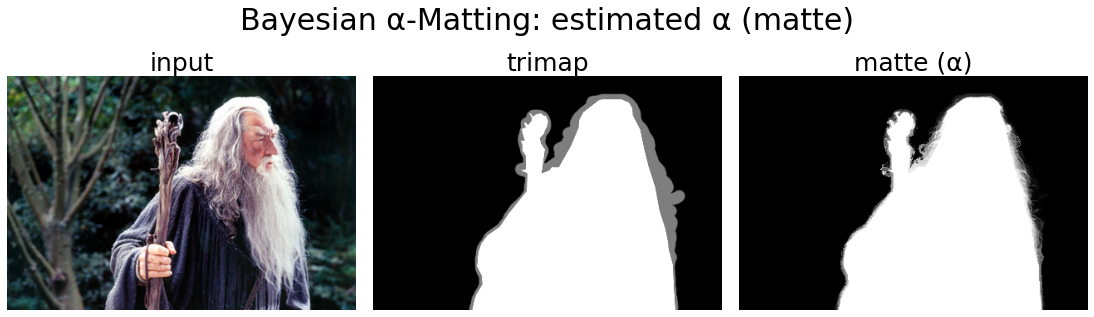

In [14]:
img = imread('images/gandalf.png')[:, :, :3]
trimap = imread('images/gandalf_trimap.png', 1)
α = bayesian_matte(img, trimap, N = 41, min_N=8) # N must be odd
plot_matte(img, trimap, α)



- The function `bayesian_matting` takes three parameters: `image` (the input image), `trimap` (a map indicating known foreground, background, and unknown regions), and `max_iter` (the maximum number of iterations for the algorithm).
- The dimensions of the image are extracted into `height` and `width`.
- An initial alpha matte (`alpha`) is created with the same height and width as the image, initialized to zeros.
- The alpha values are initialized based on the trimap:
  - Pixels with a value of 255 in the trimap are set to 1 in the alpha matte (foreground).
  - Pixels with a value of 0 in the trimap are set to 0 in the alpha matte (background).

#### Iterative Estimation



- The algorithm runs for a specified number of iterations (`max_iter`).
- For each iteration:
  - Two arrays, `F` (foreground) and `B` (background), are initialized to zeros with the same shape as the image.
  - The algorithm iterates over each pixel in the image.
  - For pixels in the unknown region (trimap value of 128):
    - The foreground color `F[i, j]` is estimated as the product of the image color and the alpha value.
    - The background color `B[i, j]` is estimated as the product of the image color and (1 - alpha value).
    - The alpha value is updated based on the distance between the image color and the estimated background color, normalized by the distance between the estimated foreground and background colors. A small value (`1e-5`) is added to the denominator to avoid division by zero.

#### Return the Alpha Matte

- The function returns the estimated alpha matte after the specified number of iterations.
This code provides a simplified implementation of Bayesian Matting. It initializes the alpha matte based on a trimap and iteratively refines the foreground and background estimates to update the alpha values. The final alpha matte represents the opacity of the foreground object at each pixel, allowing for the extraction of the foreground from the background.

In [ ]:
import numpy as np
import cv2

def bayesian_matting(image, trimap, max_iter=10):
    height, width, _ = image.shape
    alpha = np.zeros((height, width))
    
    # Initialize alpha based on trimap
    alpha[trimap == 255] = 1
    alpha[trimap == 0] = 0
    
    for _ in range(max_iter):
        F = np.zeros_like(image, dtype=np.float32)
        B = np.zeros_like(image, dtype=np.float32)
        
        for i in range(height):
            for j in range(width):
                if trimap[i, j] == 128:  # Unknown region
                    # Estimate foreground and background colors
                    F[i, j] = image[i, j] * alpha[i, j]
                    B[i, j] = image[i, j] * (1 - alpha[i, j])
                    
                    # Update alpha
                    alpha[i, j] = np.linalg.norm(image[i, j] - B[i, j]) / (np.linalg.norm(F[i, j] - B[i, j]) + 1e-5)
    
    return alpha

# Example usage
image = cv2.imread('input_image.png')
trimap = cv2.imread('trimap.png', cv2.IMREAD_GRAYSCALE)
alpha = bayesian_matting(image, trimap)

# Save the alpha matte
cv2.imwrite('alpha_matte.png', (alpha * 255).astype(np.uint8))



#### Conclusion

Bayesian Matting is a powerful technique for extracting foreground objects from images. By leveraging probabilistic models, it provides a robust framework for estimating the alpha matte. The mathematical foundations and the probabilistic approach make it a versatile tool in image processing.

For more advanced implementations and further reading, refer to the seminal research papers mentioned above. Additionally, you can find more comprehensive code examples and libraries on GitHub:

- [PyMatting](https://github.com/pymatting/pymatting): A Python library for image matting.
- [Alpha Matting](https://github.com/MarcoForte/closed-form-matting): Implementation of closed-form matting.

These resources provide a deeper dive into the algorithms and offer practical tools for implementing image matting in various applications.

## References

1. http://alphamatting.com/datasets.php
2. https://grail.cs.washington.edu/projects/digital-matting/papers/cvpr2001.pdf